# Reference-free automated single-cell cell type annotation

By 2025, algorithms for automated cell type annotation have proliferated. Omicverse is committed to reducing discrepancies between different algorithms, so we categorize automated annotation methods into two groups: `with single-cell reference` and `without single-cell reference`. Each category has its own advantages and disadvantages. In this tutorial, we will only cover usage and will not compare different algorithms.

This chapter focuses on `no single-cell reference` approaches, meaning cell type annotation can be performed without downloading existing single-cell datasets.

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(font_path='Arial')

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf


Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Data preprocess

### Load Dataset

To quickly demonstrate our capability for reference-free cell type annotation, we utilize the classic pbmc3k dataset. You can import it directly using `omicverse.datasets.pbmc3k` or download it via the link: https://falexwolf.de/data/pbmc3k_raw.h5ad.

In [2]:
adata=ov.datasets.pbmc3k()
adata

 Loading PBMC 3k dataset (raw)
⚠️ File ./data/pbmc3k_raw.h5ad already exists
 Loading data from ./data/pbmc3k_raw.h5ad


✅ Successfully loaded: 2700 cells × 32738 genes


AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

### Lazy Preprocess

Since the single dataset lacks batch effects, we directly applied the default processing workflow from omicverse for preprocessing.

In [3]:
#quantity control
adata=ov.pp.qc(adata,
              tresh={'mito_perc': 0.05, 'nUMIs': 500, 'detected_genes': 250})
#normalize and high variable genes (HVGs) calculated
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=2000,target_sum=1e4)

#save the whole genes and filter the non-HVGs
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

#scale the adata.X
ov.pp.scale(adata)

#Dimensionality Reduction
ov.pp.pca(adata,layer='scaled',n_pcs=50)

#Neighbourhood graph construction
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
               use_rep='scaled|original|X_pca')

#clusters
ov.pp.leiden(adata)

#Dimensionality Reduction for visualization(X_mde=X_umap+GPU)
ov.pp.umap(adata)
adata

🖥️ Using CPU mode for QC...
   Auto-detected mitochondrial prefix: 'MT-'

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 106                │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 13                 │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range 

   ✓ Filtered: 0 cells removed
   🔍 Normalizing data and selecting highly variable genes...

🔍 Count Normalization:
   Target sum: median
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,640 cells × 13,697 genes
   ✓ Runtime: 0.00s

🔍 Highly Variable Genes Selection:
   Method: seurat


   ⚠️ Gene indices [7846] fell into a single bin: normalized dispersion set to 1
   💡 Consider decreasing `n_bins` to avoid this effect

✅ HVG Selection Completed Successfully!
   ✓ Selected: 1,738 highly variable genes out of 13,697 total (12.7%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'dispersions': Float vector (adata.var)
     • 'dispersions_norm': Float vector (adata.var)
   🔍 Simulating synthetic doublets...
   🔍 Normalizing observed and simulated data...

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,640 cells × 1,738 genes
   ✓ Runtime: 0.00s

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 5,280 cells × 1,738 genes
   ✓ Runtime: 0.01s


   🔍 Embedding transcriptomes using PCA...
   📊 Scrublet PCA input data type (CPU) - X_obs: ndarray, shape: (2640, 1738), dtype: float64
   📊 Scrublet PCA input data type (CPU) - X_sim: ndarray, shape: (5280, 1738), dtype: float64


   🔍 Calculating doublet scores...


...

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 2,605 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 6.0551s                                                 │
│  Shape:    2,605 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit

    finished (0.54s)
    found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical)

╭─ SUMMARY: leiden ──────────────────────────────────────────────────╮
│  Duration: 0.544s                                                  │
│  Shape:    2,605 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ leiden (category)                                    │
│                                                                    │
│  ● UNS    │ ✚ leiden                                               │
│           │ └─ params: {'resolution': 1.0, 'random_state': 0, 'n_itera...│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🔍 [2026-05-17 14:41:12] Running


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 2,605 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.737s                                                  │
│  Shape:    2,605 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 2605x2)                               │
│                 

AnnData object with n_obs × n_vars = 2605 × 2000
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'leiden', 'umap'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


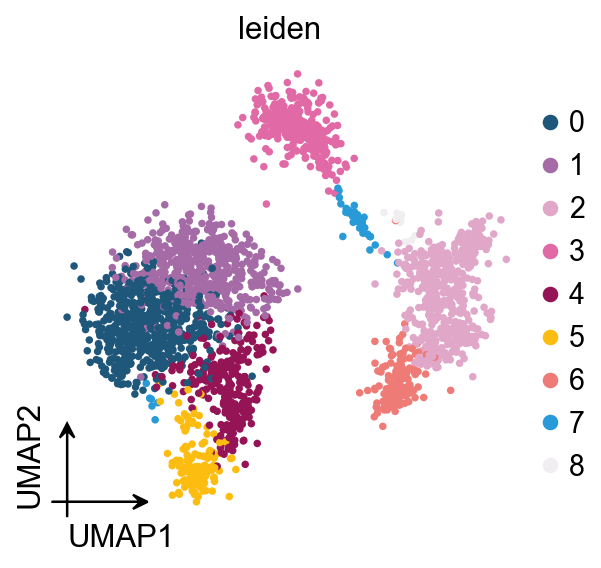

In [4]:
ov.pl.umap(
    adata,
    color='leiden'
)

## Automated Annotation

We have unified all automatic annotation algorithms into the `omicverse.single.Annotation` class.

In [5]:
obj=ov.single.Annotation(adata)

### Celltypist Automated Annotation

Here, we introduce the first algorithm, Celltypist, published in Cell and Science, which we have integrated into the automatic annotation module of Omicverse. It is important to note that to obtain the optimal pre-trained model, we have incorporated Agent for query processing.

In [6]:
res=obj.query_reference(
    source='celltypist',
    data_desc='pbmc of human',
    llm_model='gpt-5-mini',
    llm_api_key='sk-*',
    llm_provider='openai',
    llm_base_url='https://api.openai.com/v1',
)
res.head()

CellTypist model table saved to self.celltypist_models_df
⚠️ LLM setup failed (Missing API key for LLM provider 'openai'. Provide via `llm_api_key` or set the corresponding environment variable.). Fallback to first model (LLM unavailable or returned no results).
✓ LLM-selected CellTypist models:
  - Immune_All_Low.pkl: Immune_All_Low.pkl


,model,description,version,No_celltypes,source,date,default,llm_reason
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...,v2,98,https://doi.org/10.1126/science.abl5197,2022-07-16 00:20:42.927778,True,Fallback to first model (LLM unavailable or re...


Based on the LLM's recommendation, we found that `Immune_All_Low.pkl` is the model best suited for our data. Then we use `download_reference_pkl` function to download this model.

In [7]:
!pwd

/tmp/anno_noref_exec


In [8]:
obj.download_reference_pkl(
    'Immune_All_Low.pkl',
    save_path="/scratch/users/steorra/analysis/omic_test/models/Immune_All_Low.pkl",
    #force_download=True
)

🔍 Downloading data to /scratch/users/steorra/analysis/omic_test/models/Immune_All_Low.pkl
⚠️ File /scratch/users/steorra/analysis/omic_test/models/Immune_All_Low.pkl already exists
https://celltypist.cog.sanger.ac.uk/models/Pan_Immune_CellTypist/v2/Immune_All_Low.pkl
✓ Model saved to /scratch/users/steorra/analysis/omic_test/models/Immune_All_Low.pkl


'/scratch/users/steorra/analysis/omic_test/models/Immune_All_Low.pkl'

After download the model, we need to load it to our Annotation class.

In [9]:
obj.add_reference_pkl('/scratch/users/steorra/analysis/omic_test/models/Immune_All_Low.pkl')

In [10]:
obj.model.cell_types[:5]

array(['Age-associated B cells', 'Alveolar macrophages', 'B cells',
       'CD16+ NK cells', 'CD16- NK cells'], dtype=object)

In [11]:
obj.annotate(
    method='celltypist'
)

INFO:celltypist.logger:🔬 Input data has 2605 cells and 2000 genes


INFO:celltypist.logger:🔗 Matching reference genes in the model


INFO:celltypist.logger:🧬 1043 features used for prediction


INFO:celltypist.logger:⚖️ Scaling input data


INFO:celltypist.logger:🖋️ Predicting labels


...

INFO:celltypist.logger:👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it


INFO:celltypist.logger:⛓️ Over-clustering input data with resolution set to 5


INFO:celltypist.logger:🗳️ Majority voting the predictions


INFO:celltypist.logger:✅ Majority voting done!


Celltypist prediction saved to adata.obs['celltypist_prediction']
Celltypist decision matrix saved to adata.obsm['celltypist_decision_matrix']
Celltypist probability matrix saved to adata.obsm['celltypist_probability_matrix']


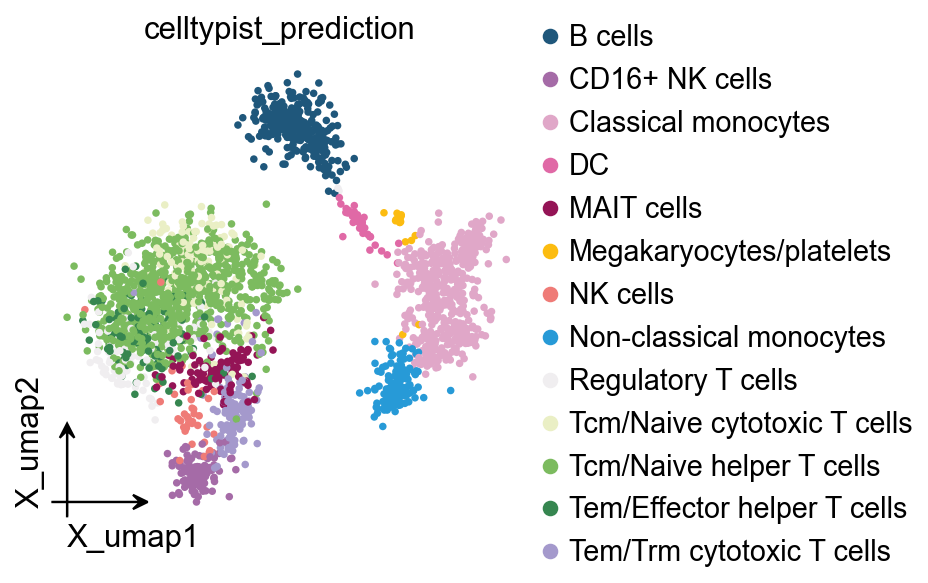

In [12]:
ov.pl.embedding(
    obj.adata,
    basis='X_umap',
    color='celltypist_prediction'
)

### gpt4celltype Automated Annotation

Besides, we also provide the gpt4celltype to annotate the celltype automatically. 

In [13]:
import os
# Set AGI_API_KEY before running the notebook; e.g.
#   export AGI_API_KEY=sk-your-actual-key
# See https://platform.deepseek.com/api_keys (DeepSeek) or your
# preferred OpenAI-compatible provider for how to obtain one.
assert os.environ.get('AGI_API_KEY'), (
    'AGI_API_KEY is not set. Export it before running this notebook.'
)

obj=ov.single.Annotation(adata)
result = obj.annotate(
    method='gpt4celltype',
    tissuename='PBMC', speciename='human',
    model='deepseek-chat', provider='openai',
    base_url='https://api.deepseek.com/v1',
    topgenenumber=5 
)

... storing 'celltypist_prediction' as categorical


...get cell type marker


Note: AGI API key found: returning the cell type annotations.


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.
GPT4celltype prediction saved to adata.obs['gpt4celltype_prediction']


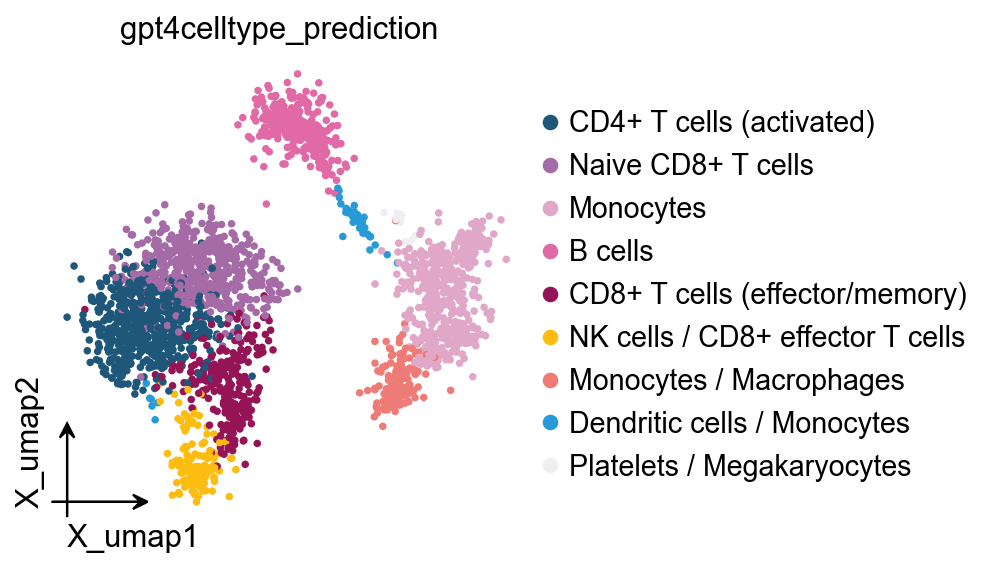

In [14]:
ov.pl.embedding(
    obj.adata,
    basis='X_umap',
    color='gpt4celltype_prediction'
)

### SCSA Automated Annotation

We haved a clearly detailed tutorial of SCSA in https://omicverse.readthedocs.io/en/latest/Tutorials-single/t_cellanno/

Here, we only provided a simple tutorial to demonstrate the ability of Annotation class.

In [15]:
obj=ov.single.Annotation(adata)

To perform the SCSA automated annotation, we need to download the database at first.

In [16]:
obj.download_scsa_db(
    'temp/pySCSA_2024_v1_plus.db'
)

Trying to download from Stanford...
🔍 Downloading data to temp/pySCSA_2024_v1_plus.db
⚠️ File temp/pySCSA_2024_v1_plus.db already exists
SCSA database saved to temp/pySCSA_2024_v1_plus.db


'temp/pySCSA_2024_v1_plus.db'

In [17]:
obj.add_reference_scsa_db(
    'temp/pySCSA_2024_v1_plus.db'
)

In [18]:
obj.annotate(
    method='scsa',
    cluster_key='leiden',
    foldchange=1.5,
    pvalue=0.01,
    celltype='normal',
    target='cellmarker',
    tissue='All',  
)

ranking genes


    finished (0:00:00)


...Auto annotate cell


🔍 Version V2.2 [2024/12/18]
📊 DB load: GO_items:47347, Human_GO:3, Mouse_GO:3,
           CellMarkers:82887, CancerSEA:1574, PanglaoDB:24223
           Ensembl_HGNC:61541, Ensembl_Mouse:55414


🔍 Version V2.2 [2024/12/18]
📊 DB load: GO_items:47347, Human_GO:3, Mouse_GO:3,
           CellMarkers:82887, CancerSEA:1574, PanglaoDB:24223
           Ensembl_HGNC:61541, Ensembl_Mouse:55414
📦 Load markers: 70276

🔬 Analyzing 9 clusters...



...

[5/9]      Cluster 4    │ 45   genes │ 1005 other genes


[6/9]      Cluster 5    │ 159  genes │ 924  other genes


[7/9]      Cluster 6    │ 433  genes │ 842  other genes


[8/9]      Cluster 7    │ 288  genes │ 877  other genes


[9/9]      Cluster 8    │ 128  genes │ 940  other genes

✅ Cluster analysis completed! (9/9 processed)


📋 Cell Type Annotation Results

Cluster    Type     Cell Type                           Score           Times
--------------------------------------------------------------------------------
0          ⚠️ ?      T cell|CD4+ T cell                  9.112033735282516|5.2548303193683505 1.73
1          ⚠️ ?      T cell|Naive CD8+ T cell            5.165952802767895|4.4302275893812055 1.17
2          ⚠️ ?      Monocyte|Macrophage                 14.368055481798159|8.508378157687567 1.69
3          ✅ Good   B cell                              13.782018628915111 4.01
4          ⚠️ ?      Natural killer cell|T cell          7.824364750715023|6.636980057576664 1.18
5          ✅ Good   Natural killer cell                 15.297212653962205 3.79
6          ⚠️ ?      Monocyte|Macrophage                 10.834925361082918|8.657124405135688 1.25
7          ⚠️ ?      Dendritic cell|Monocyte      

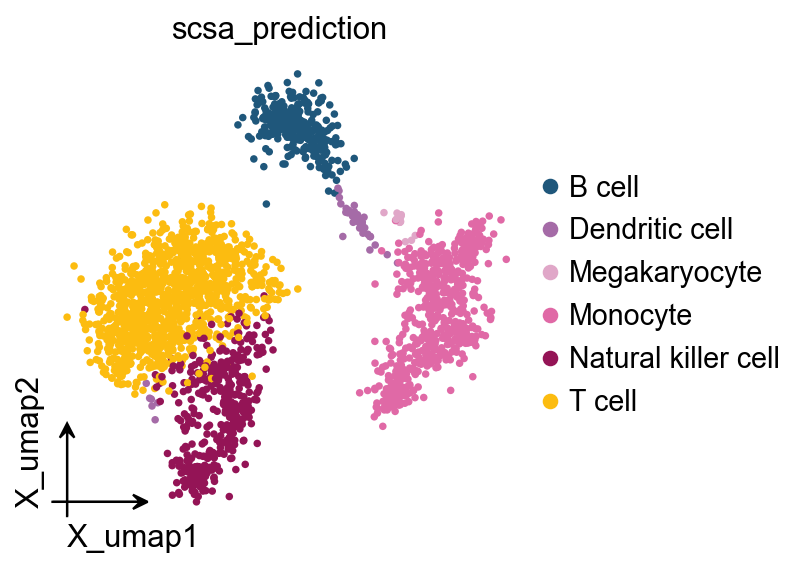

In [19]:
ov.pl.embedding(
    obj.adata,
    basis='X_umap',
    color='scsa_prediction'
)

### scMulan Automated Annotation

`scMulan` (Bian et al., *Nature Methods* 2024) is a transformer-based
foundation model trained on a large multi-tissue single-cell atlas. It
predicts a cell-type label per cell directly — no marker dictionary or
reference dataset needed — and is now wired into
`ov.single.Annotation` alongside celltypist / scsa / gpt4celltype.

The integrated workflow handles three things automatically:

1. **Gene-symbol uniformization** — `GeneSymbolUniform` rewrites
   `adata.var_names` onto the gene panel scMulan was trained against
   (default `uniform_genes=True`).
2. **Conditional normalisation** — if `X.max() > 10` the matrix is
   `normalize_total(1e4) + log1p`-ed; otherwise it's left alone.
3. **Optional smoothing pass** — `smoothing_threshold=0.1` filters
   false-positive predictions by neighbour consensus (set to `None`
   to skip).

Two prediction columns are written back to `adata.obs`:

| column | meaning |
|---|---|
| `scMulan_prediction` | raw model output |
| `scMulan_smoothed_prediction` | post-hoc neighbour-smoothed label |


In [20]:
obj = ov.single.Annotation(adata)

The checkpoint (≈ 1 GB) lives on the Tsinghua cloud mirror.
`download_scmulan_ckpt` caches it locally so subsequent runs skip the
download.

In [21]:
obj.download_scmulan_ckpt(
    save_path='./ckpt/ckpt_scMulan.pt',
    # force_download=True,
)

scMulan checkpoint already present at ./ckpt/ckpt_scMulan.pt; pass force_download=True to overwrite.


'./ckpt/ckpt_scMulan.pt'

`annotate(method='scMulan')` runs gene uniformization, normalisation,
inference, and (by default) the smoothing pass in one call. Pass
`parallel=False` / `n_process=1` to fall back to single-threaded CPU
inference.

In [22]:
obj.annotate(
    method='scMulan',
    smoothing_threshold=0.1,
    parallel=False,        # multi-process hangs on some systems; CPU/GPU single-process is fast enough
)

{message}


The shape of query data is: (2605, 2000)
The length of reference gene_list is: 42117
Performing gene symbol uniform, this step may take several minutes


Processing:   0%|                                                                                                 | 0/2000 [00:00<?, ?it/s]

Processing:   8%|██████▊                                                                              | 159/2000 [00:00<00:01, 1587.19it/s]

Processing:  17%|██████████████▊                                                                      | 348/2000 [00:00<00:00, 1757.76it/s]

...

 80%|████████████████████████████████████████████████████████████████████████████▎                   | 2072/2605 [00:00<00:00, 3368.91it/s]

 93%|█████████████████████████████████████████████████████████████████████████████████████████▍      | 2426/2605 [00:00<00:00, 3420.42it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 2605/2605 [00:00<00:00, 3377.37it/s]

scMulan smoothed prediction saved to adata.obs['scMulan_smoothed_prediction']


AnnData object with n_obs × n_vars = 2605 × 2000
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden', 'celltypist_prediction', 'gpt4celltype_prediction', 'scsa_prediction', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score'
    uns: 'Smoothing', 'cell_type_from_scMulan_colors', 'cell_type_from_mulan_smoothing_colors'
    obsm: 'X_scMulan'
    obsp: 'Smoothing_distances', 'Smoothing_connectivities'

Visualise the raw vs smoothed scMulan labels side by side.

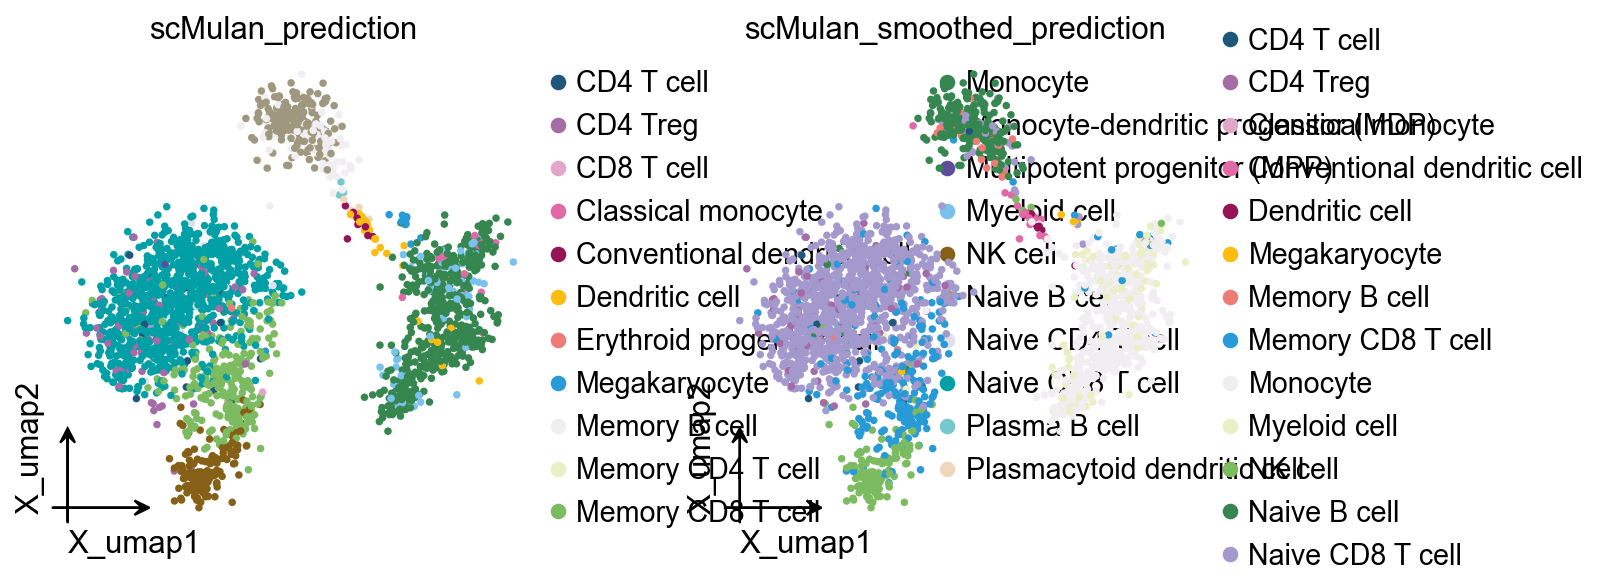

In [23]:
ov.pl.embedding(
    obj.adata,
    basis='X_umap',
    color=['scMulan_prediction', 'scMulan_smoothed_prediction'],
    ncols=2, frameon='small',
)

### MetaTiME Automated Annotation

`MetaTiME` (Yan et al., *Nature Communications* 2023) projects each cell
onto a bank of pre-computed meta-components (MeCs) learned from a large
multi-cancer single-cell atlas, then assigns a tumor-microenvironment
cell-state label per overclustered group. With the new
`ov.single.Annotation` integration the full workflow — overclustering,
MeC projection, label assignment — is a single call.

| column | meaning |
|---|---|
| `MetaTiME` | fine cell-state label (e.g. `Mφ_TAM_C1QC`) |
| `Major_MetaTiME` | coarse celltype prefix (e.g. `Mφ`) |
| `MetaTiME_prediction` | alias of `MetaTiME` for CellVote compatibility |

> Note: MetaTiME is designed for tumor microenvironment data; PBMC3k is
> a healthy-blood dataset, so labels will fall back to whichever MeCs
> are nearest in the gene-program space — useful as a sanity check
> rather than the model's intended use case.


In [24]:
obj = ov.single.Annotation(adata)
obj.annotate(
    method='MetaTiME',
    mode='table',
    resolution=8,
    save_obs_name='MetaTiME',
)

metatime have been install version: 1.3.0
...load pre-trained MeCs


...load functional annotation for MetaTiME-TME
...overclustering using leiden
running Leiden clustering


    finished (0:00:00)


...projecting MeC scores


......The predicted celltype have been saved in obs.MetaTiME
......The predicted major celltype have been saved in obs.Major_MetaTiME
MetaTiME prediction saved to adata.obs['MetaTiME'] (alias: adata.obs['MetaTiME_prediction'])


Visualise the fine MetaTiME labels and the coarse-grained Major_MetaTiME side by side.

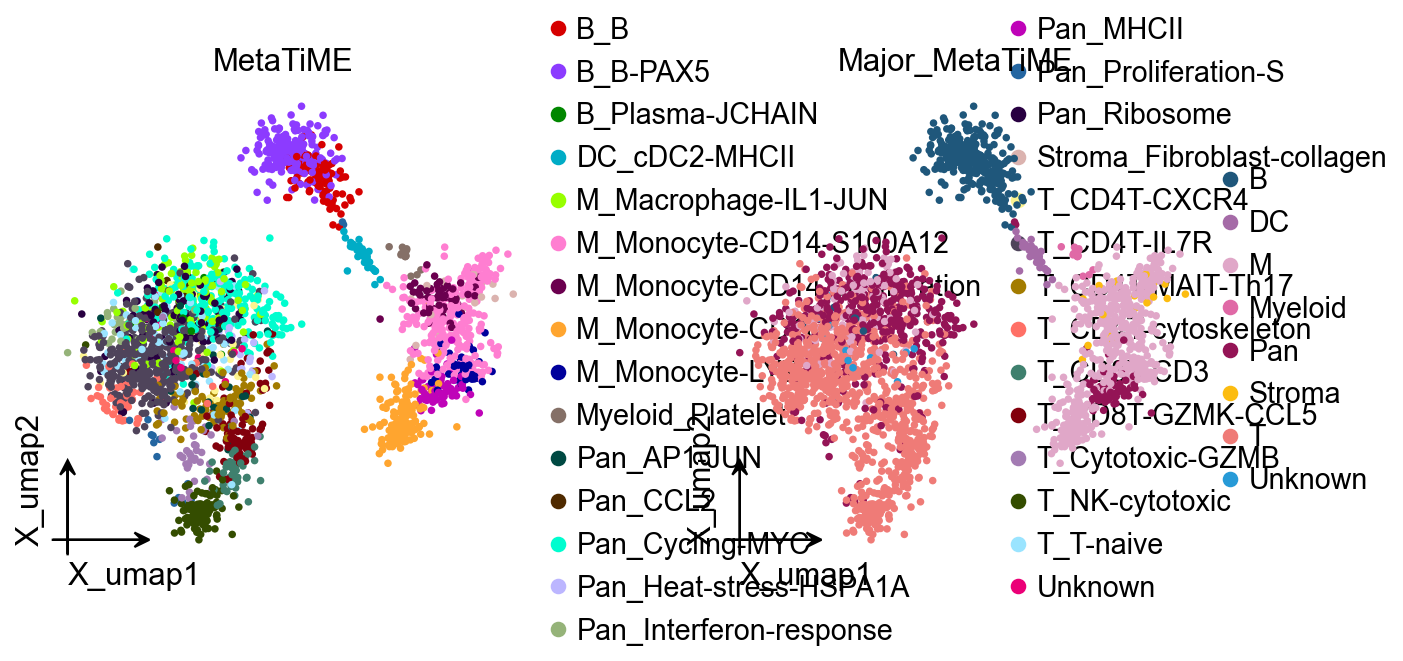

In [25]:
ov.pl.embedding(
    obj.adata,
    basis='X_umap',
    color=['MetaTiME', 'Major_MetaTiME'],
    ncols=2, frameon='small',
)